In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Семинар 1 · Ноутбук 2
# Преобразование таргета

До сих пор мы прогнозировали ряд «как есть» — и молчаливо предполагали, что в нём нет дыр.
В реальности это редкость: датчик отключился на день, магазин не работал в праздник, а иногда
ряды к тому же ведут себя неудобно — разброс значений растёт вместе с уровнем, распределение
перекошено, а прогноз обязан оставаться положительным или лежать в заданном диапазоне. Второй
набор проблем решает **преобразование таргета** — мы прогнозируем не исходный ряд $y_t$, а его
преобразованную версию $z_t = f(y_t)$, а затем возвращаемся обратно $ \hat y = f^{-1}(\hat z)$.

Ноутбук состоит из двух частей. В **части I** мы всё делаем руками — по формулам, на `numpy` и
`scipy`, чтобы видеть каждый шаг целиком. В **части II** те же самые задачи решаются
«из коробки» средствами трёх библиотек курса, и главное там — не сами преобразования, а
**автоматическое обратное преобразование внутри пайплайна прогнозирования**: именно на нём (в
разделе 4 части I) прячется главная возможность ошибиться.

| Раздел | Вопрос, на который отвечаем |
|---|---|
| **Часть I. Руками** | |
| 0 | Как заполнить пропуски в ряде — и почему это нужно сделать **до** любых преобразований |
| 1 | Как стабилизировать дисперсию: корень, кубический корень, логарифм |
| 2 | Как подобрать параметр $\lambda$ семейства **Бокса–Кокса** |
| 3 | Что делать, если в ряду есть нули или отрицательные значения — **Йео–Джонсон** |
| 4 | Как вернуть прогноз в исходную шкалу и не забыть про **корректировку смещения** |
| 5 | Как удержать прогноз в заданном диапазоне $[a,b]$ — логарифм и логит |
| 6 | Как преобразование меняет **ширину интервалов прогноза** |
| **Часть II. Во фреймворках** | |
| 7 | `statsforecast` / `coreforecast` / `utilsforecast` — функции над `numpy`-массивами |
| 8 | `sktime` — sklearn-стиль: объекты с `fit`/`transform`/`inverse_transform` |
| 9 | `etna` — преобразования внутри контейнера `TSDataset` и пайплайна |
| 10 | Сводная таблица: одна и та же задача — три интерфейса |

🔍 Чего сегодня **не** будет: поиска аномалий и выбросов — это отдельное занятие, вместе с
темой пропусков они образуют «диагностику ряда», но выбросы устроены иначе и заслуживают
отдельного разбора. Также за рамками остаются подробности `mlforecast` (в окружении курса его
нет — только справочный пример в тексте) и кросс-валидация с преобразованиями — это Семинар 2.

> **Требуются библиотеки:** `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`,
> `statsmodels`, `statsforecast`, `coreforecast`, `utilsforecast`, `sktime`, `etna`.
> Данные — `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/a10.csv`, `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/a10_missings.csv`,
> `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/weekly_flat.csv`, `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/aus-production.csv`.

> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит обратить
> внимание особо: там прячутся типичные ошибки новичков.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams["figure.figsize"] = (14, 5)

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


---
# Часть I. Преобразования руками

---
## 0. Пропуски: почему это первый шаг

Логарифм и Бокс–Кокс считаются поточечно: одна пропущенная дата — и вся последующая формула
либо падает с ошибкой на `NaN`, либо (что хуже) молча портит статистику, которая использует
весь ряд разом (среднее, дисперсию, автокорреляцию). Поэтому первый шаг всегда один и тот же:
разобраться, откуда взялся пропуск, и только потом решать, чем его заполнять.

### 0.1. Три источника пропуска

«Пропуск» в реальных данных — это не одна и та же проблема:

| Источник | Что это значит | Пример |
|---|---|---|
| Не собрали | наблюдение существовало, но не было измерено | датчик отключился, отчёт не прислали |
| Не было события | в этот момент величина объективно не определена | магазин был закрыт, товара не было в продаже |
| Не изменилось | значение специально не публикуют, пока оно совпадает с прошлым | цена, курс — публикуют только при изменении |

🔍 Наивная идея «заполнить пропуск средним по ряду» здесь почти всегда ошибка: временной ряд
обычно **нестационарен** — среднее за 2008 год ничего не говорит о значении в январе 1995-го.
Вместо этого нужно смотреть на **контекст** (что означает пропуск содержательно) и на
**структуру** ряда (тренд, сезонность) — этим и займёмся ниже.

In [2]:
# a10: полный ряд без пропусков — эталон для проверки качества заполнения
a10 = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/a10.csv",
    parse_dates=["Month"],
).rename(columns={"Month": "date", "Cost": "value"})
a10_truth = a10["value"].to_numpy()[:100]  # первые 100 точек — на них считаем ошибку

# a10_missings: тот же участок ряда, но с искусственно пробитыми точками
a10_gaps = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/a10_missings.csv",
    parse_dates=["date"],
)
gap_mask = a10_gaps["value"].isna().to_numpy()
print(f"продажи противодиабетических препаратов (Австралия), первые {len(a10_gaps)} месяцев")
print(f"пропущено {gap_mask.sum()} точек из {len(a10_gaps)} ({gap_mask.mean():.0%})")

продажи противодиабетических препаратов (Австралия), первые 100 месяцев
пропущено 31 точек из 100 (31%)


### 0.2. Бенчмарк методов заполнения

Сравним шесть стандартных способов «наивного» заполнения на ряде с пропусками, зная истинные
значения. 🔍 Ошибку нужно считать **только по пропущенным точкам** — если добавить в MSE точки,
где пропуска не было, они совпадут тривиально и завысят кажущееся качество метода.

In [3]:
v = a10_gaps["value"].to_numpy()
rownum = np.arange(len(v))
observed = ~gap_mask

filled = {}
filled["forward fill"] = a10_gaps["value"].ffill().to_numpy()
filled["backward fill"] = a10_gaps["value"].bfill().to_numpy()
filled["линейная интерполяция"] = interp1d(rownum[observed], v[observed])(rownum)
filled["кубическая интерполяция"] = interp1d(rownum[observed], v[observed], kind="cubic")(rownum)


def knn_mean(ts, n):
    """Среднее n ближайших по индексу наблюдений (без учёта времени и сезонности)."""
    out = np.copy(ts)
    for i, val in enumerate(ts):
        if np.isnan(val):
            half = int(np.ceil(n / 2))
            lo, hi = max(0, i - half), min(len(ts), i + half)
            out[i] = np.nanmean(np.concatenate([ts[lo:i], ts[i:hi]]))
    return out


def seasonal_mean(ts, period):
    """Среднее по всем наблюдениям того же сезона (месяца), включая прошлые и будущие."""
    out = np.copy(ts)
    for i, val in enumerate(ts):
        if np.isnan(val):
            out[i] = np.nanmean(ts[i % period :: period])
    return out


filled["среднее 8 соседей"] = knn_mean(v, 8)
filled["среднее по сезону"] = seasonal_mean(v, 12)

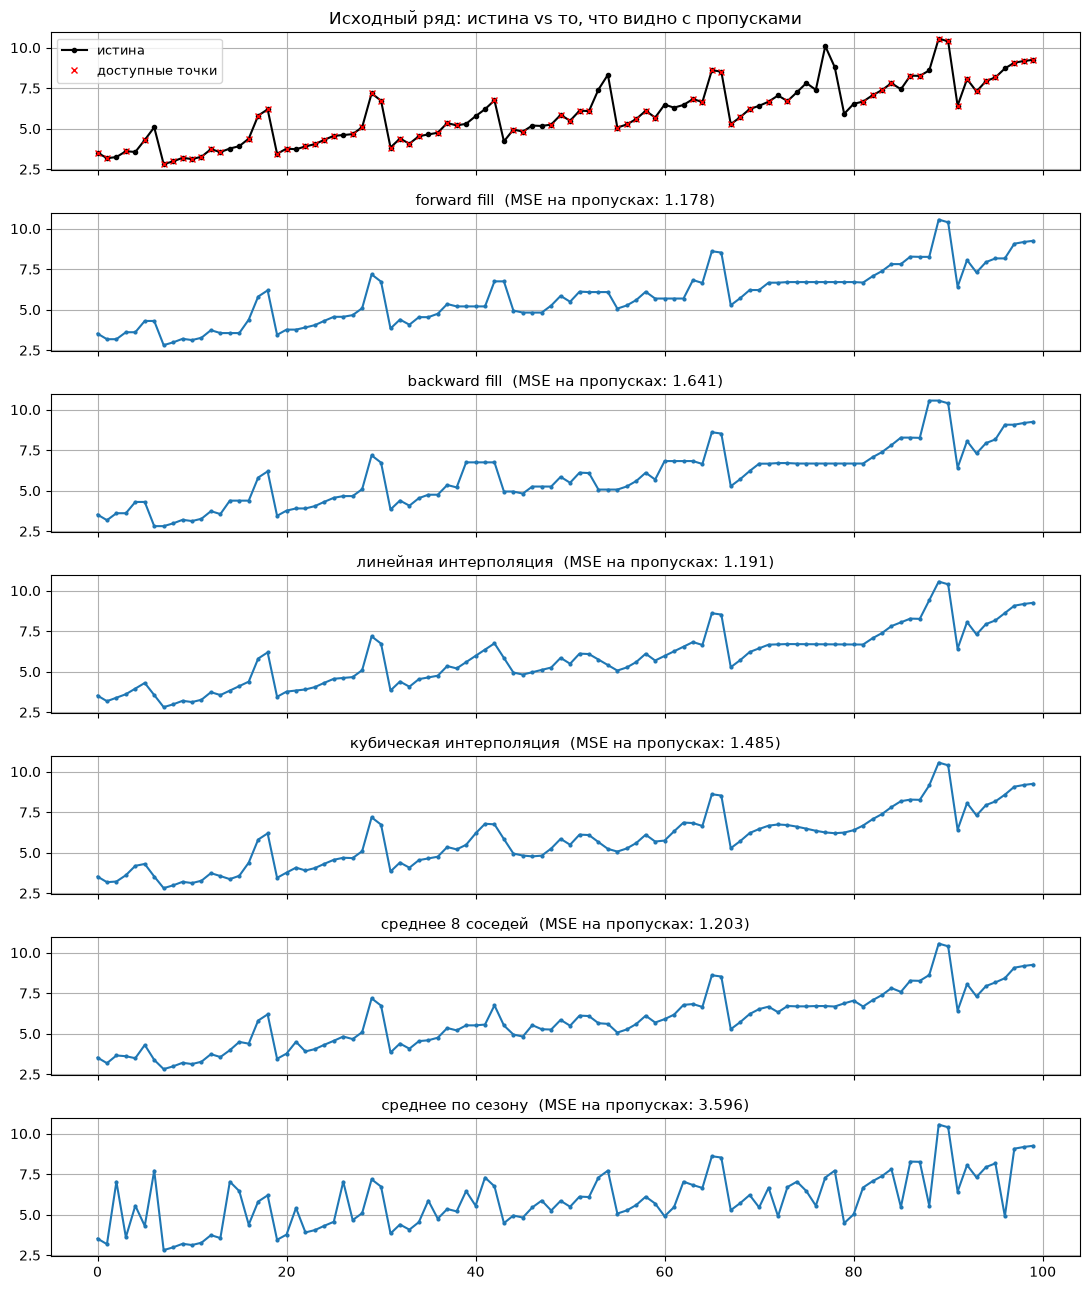

In [4]:
fig, axes = plt.subplots(len(filled) + 1, 1, sharex=True, figsize=(11, 13))
axes[0].plot(a10_truth, "k.-", label="истина")
axes[0].plot(v, "rx", ms=5, label="доступные точки")
axes[0].set_title("Исходный ряд: истина vs то, что видно с пропусками")
axes[0].legend(fontsize=9)
for ax, (name, arr) in zip(axes[1:], filled.items()):
    mse_gap = mean_squared_error(a10_truth[gap_mask], arr[gap_mask])
    ax.plot(arr, ".-", ms=4)
    ax.set_title(f"{name}  (MSE на пропусках: {mse_gap:.3f})", fontsize=11)
for ax in axes:
    ax.grid()
plt.tight_layout()
plt.show()

`forward fill` и линейная интерполяция здесь ошибаются меньше всего, кубическая интерполяция
«перелетает» между соседними точками из-за шума, а **среднее по сезону хуже всех** — оно
полностью игнорирует растущий тренд ряда и тянет заполненную точку к среднему уровню всей
истории. 🔍 Вывод не «сезонное среднее — плохой метод», а «метод нужно выбирать по структуре
конкретного ряда»: для ряда с сильным трендом сезонное среднее без поправки на тренд проиграет
почти всегда.

### 0.3. Смотрим на контекст

Иногда сам смысл данных подсказывает правильный метод без всякого бенчмарка. Ниже — недельные
цены на сырьё: пропуск здесь означает **«цена не изменилась»**, а не «мы не знаем цену».

пропущено 25 недель из 912


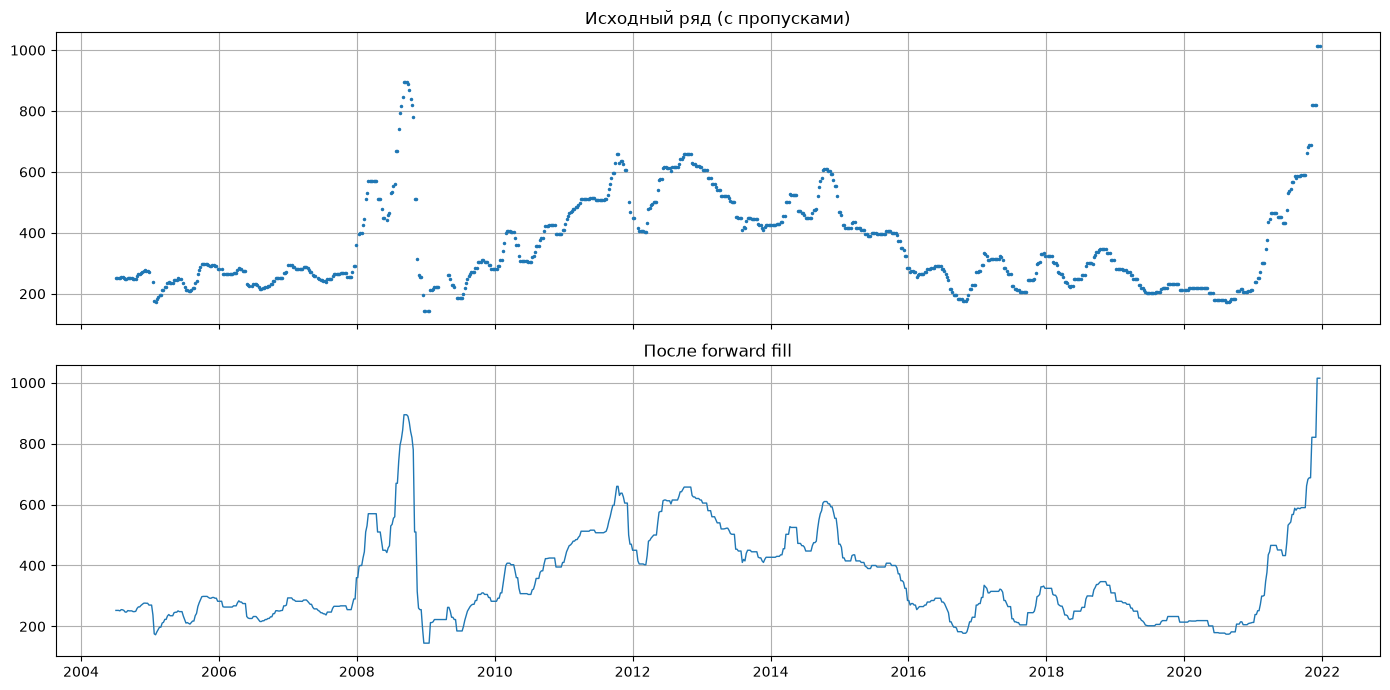

In [5]:
weekly = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/weekly_flat.csv",
    index_col=0,
    parse_dates=True,
)
print(f"пропущено {weekly['value'].isna().sum()} недель из {len(weekly)}")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 7))
axes[0].plot(weekly["value"], ".", ms=3)
axes[0].set_title("Исходный ряд (с пропусками)")
axes[1].plot(weekly["value"].ffill(), "-", lw=1)
axes[1].set_title("После forward fill")
for ax in axes:
    ax.grid()
plt.tight_layout()
plt.show()

`forward fill` здесь содержательно верен: до следующего изменения цена оставалась прежней. Да,
это слегка занижает дисперсию ряда, но не придумывает данных — в отличие, например, от линейной
интерполяции, которая нарисовала бы плавный переход там, где в реальности была ровная полка.

### 0.4. Смотрим на структуру: тренд и сезонность

Когда контекст не подсказывает метод напрямую, помогает **структура** ряда — тренд и
сезонность. Возьмём квартальный ВВП США (`statsmodels.datasets.macrodata`) и вырежем случайные
20% точек.

In [6]:
macro = sm.datasets.macrodata.load_pandas().data
macro.index = pd.period_range(start="1959Q1", periods=len(macro), freq="Q").to_timestamp()
macro = macro.drop(columns=["year", "quarter"])

rng = np.random.default_rng(0)
gdp_mask = rng.binomial(1, 0.2, size=len(macro)) > 0
gdp_true = macro["realgdp"]
gdp_nan = gdp_true.copy()
gdp_nan[gdp_mask] = np.nan
print(f"пропущено {gdp_mask.sum()} кварталов из {len(macro)}")


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

пропущено 55 кварталов из 203


`pandas.Series.interpolate` умеет учитывать **тип индекса**: `method="linear"` интерполирует по
номеру точки, а `method="time"` — по фактическому расстоянию во времени между наблюдениями
(важно, если шаг между датами неравномерный).

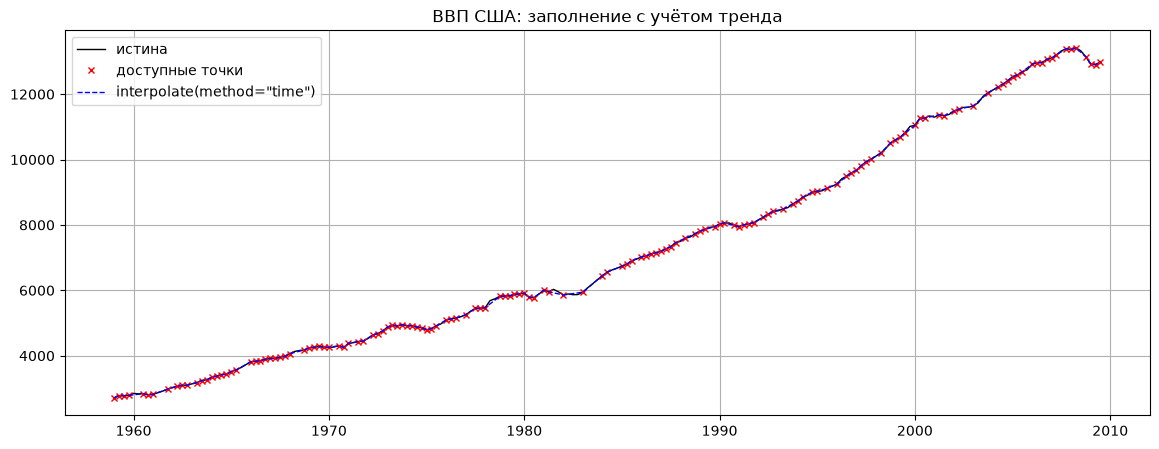

MAPE linear: 0.37%
MAPE time:   0.37%


In [7]:
gdp_linear = gdp_nan.interpolate(method="linear")
gdp_time = gdp_nan.interpolate(method="time")

fig, ax = plt.subplots()
ax.plot(gdp_true, "k-", lw=1, label="истина")
ax.plot(gdp_nan, "rx", ms=5, label="доступные точки")
ax.plot(gdp_time, "b--", lw=1, label='interpolate(method="time")')
ax.set_title("ВВП США: заполнение с учётом тренда")
ax.legend(fontsize=10)
ax.grid()
plt.show()

print(f"MAPE linear: {mape(gdp_true[gdp_mask], gdp_linear[gdp_mask]):.2f}%")
print(f"MAPE time:   {mape(gdp_true[gdp_mask], gdp_time[gdp_mask]):.2f}%")

Для равномерной квартальной сетки `"linear"` и `"time"` совпадают — разница появится, если в
индексе будут неравные интервалы между датами (например, при удалении части точек, а не только
обнулении значений).

Более гибкий вариант — **модельное заполнение**: обучить сглаживающую модель на наблюдаемых
точках и предсказать пропущенные. Ниже — локальная регрессия LOWESS
(`statsmodels.nonparametric.smoothers_lowess.lowess`).

In [8]:
observed_idx = np.flatnonzero(~gdp_mask)
gap_idx = np.flatnonzero(gdp_mask)

smoothed = lowess(
    endog=gdp_nan.to_numpy()[observed_idx],
    exog=observed_idx,
    frac=0.15,
    xvals=np.arange(len(macro)),
)
gdp_lowess = gdp_nan.copy()
gdp_lowess.iloc[gap_idx] = smoothed[gap_idx]

print(f"MAPE LOWESS: {mape(gdp_true[gdp_mask], gdp_lowess[gdp_mask]):.2f}%")

MAPE LOWESS: 1.51%


На этом ряде простая интерполяция по времени справляется не хуже LOWESS — у ВВП тренд почти
линейный на коротких участках. Выигрыш модельного заполнения растёт с нелинейностью тренда и
долей пропусков.

Отдельный частный случай структуры — **сезонная аналогия**: заполнить пропуск средним по
соседним периодам того же сезона (например, средним значением за предыдущий и следующий год).

In [9]:
seasonal = macro["pop"].diff().dropna().tail(80)  # прирост населения, поквартально
seas_mask = np.random.default_rng(0).binomial(1, 0.1, size=len(seasonal)) > 0
seasonal_nan = seasonal.copy()
seasonal_nan[seas_mask] = np.nan

# 🔍 сдвиги берём от ряда С ПРОПУСКАМИ (seasonal_nan), а не от исходного seasonal — иначе в
# заполнение незаметно подмешается сама истина, которую мы как будто не знаем
previous_year = seasonal_nan.shift(4)
next_year = seasonal_nan.shift(-4)
seasonal_avg = pd.concat([previous_year, next_year], axis=1).mean(axis=1)  # nanmean по строке

seasonal_filled = seasonal_nan.copy()
seasonal_filled[seasonal_filled.isna()] = seasonal_avg[seasonal_filled.isna()]
seasonal_filled = seasonal_filled.ffill().bfill()  # у краёв ряда соседнего года может не быть

print(f"MAPE сезонной аналогии: {mape(seasonal[seas_mask], seasonal_filled[seas_mask]):.2f}%")

MAPE сезонной аналогии: 6.07%


🔍 На краях ряда (первые/последние 4 квартала) сдвиг на год мог смотреть за пределы данных — эти
точки пришлось дозаполнить `ffill`/`bfill`. Это нормально для учебного примера, но напоминание:
заполненное значение **не является наблюдением** — на нём нельзя доучивать модель или проверять
итоговое качество прогноза, только использовать как входные данные.

### 0.5. Итог: как выбирать метод

| Что известно о пропуске | Метод |
|---|---|
| Ничего, ряд без выраженной структуры | `ffill`/`bfill`, линейная интерполяция |
| Пропуск = «значение не изменилось» | `ffill` |
| Есть выраженный тренд | интерполяция `method="time"`, модельное заполнение |
| Есть выраженная сезонность | среднее по аналогичным сезонам (с поправкой на тренд) |
| Пропусков много, нужна гибкая кривая | LOWESS / другая сглаживающая модель |

Дальше в этом ноутбуке ряды уже очищены от пропусков — переходим к самой теме преобразований.

---
## 1. Стабилизация дисперсии

Если разброс ряда меняется во времени (обычно **растёт** вместе с уровнем), говорят о непостоянной дисперсии. Прогнозным моделям это мешает: они неявно предполагают, что «шум» одинаков на всём интервале. Классический пример из лекции — **производство электроэнергии** в Австралии: и уровень, и амплитуда сезонных колебаний растут год от года.

Возьмём квартальный ряд `Electricity`.

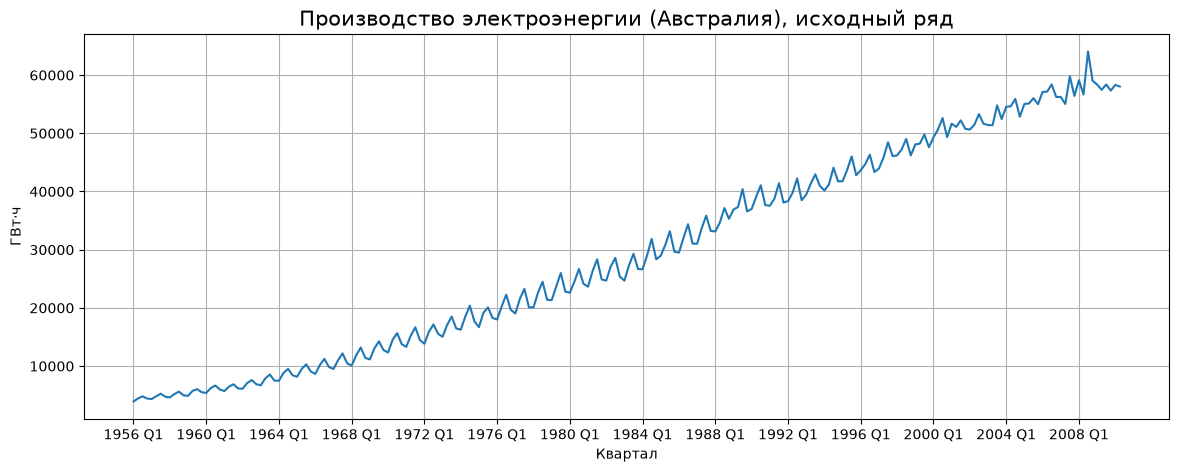

In [10]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/aus-production.csv",
    sep=";",
)
elec = df[["Quarter", "Electricity"]].dropna().reset_index(drop=True)
y = elec["Electricity"].values.astype(float)

fig, ax = plt.subplots()
ax.plot(elec["Quarter"], y, lw=1.5)
ax.set_title("Производство электроэнергии (Австралия), исходный ряд", fontsize=15)
ax.set_ylabel("ГВт·ч")
ax.set_xlabel("Квартал")
ax.set_xticks(np.arange(0, len(elec), 16))
ax.grid()
plt.show()

Обозначим исходный ряд $y_1,\dots,y_n$, а преобразованный — $z_1,\dots,z_n$. Три «ступеньки» стабилизации по силе воздействия:

| Преобразование | Формула | Сила |
|---|---|---|
| Квадратный корень | $z_t=\sqrt{y_t}$ | слабая |
| Кубический корень | $z_t=\sqrt[3]{y_t}$ | средняя |
| Логарифм | $z_t=\log(y_t)$ | сильная |

Логарифм особенно удобен своей **интерпретируемостью**: изменения в лог-шкале — это относительные (процентные) изменения в исходной шкале.

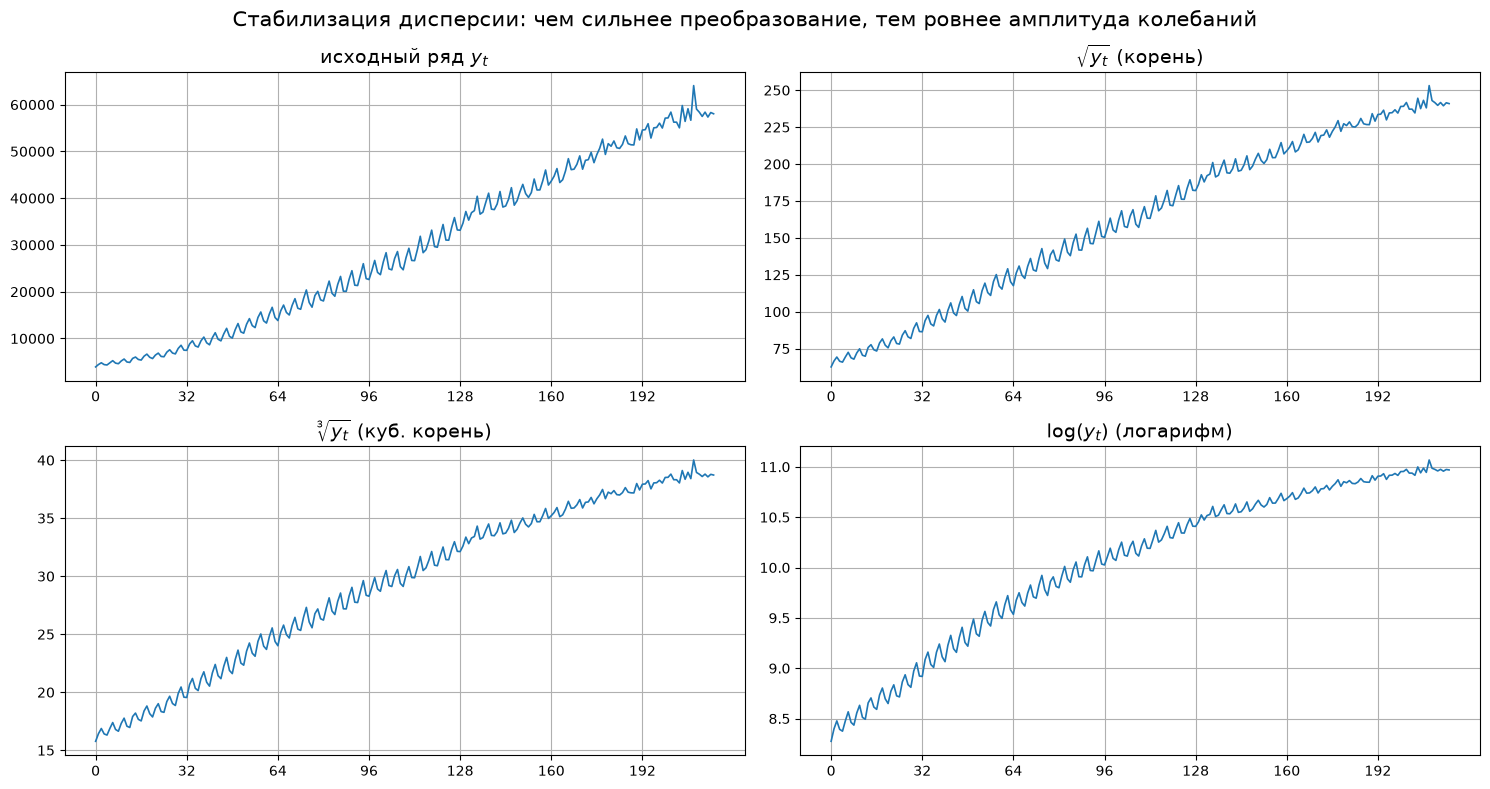

In [11]:
transforms = {
    "исходный ряд $y_t$": y,
    r"$\sqrt{y_t}$ (корень)": np.sqrt(y),
    r"$\sqrt[3]{y_t}$ (куб. корень)": np.cbrt(y),
    r"$\log(y_t)$ (логарифм)": np.log(y),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (name, z) in zip(axes.ravel(), transforms.items()):
    ax.plot(z, lw=1.2)
    ax.set_title(name, fontsize=14)
    ax.set_xticks(np.arange(0, len(z), 32))
    ax.grid()
fig.suptitle(
    "Стабилизация дисперсии: чем сильнее преобразование, тем ровнее амплитуда колебаний",
    fontsize=15,
)
plt.tight_layout()
plt.show()

Видно, как с усилением преобразования амплитуда сезонных колебаний в начале и в конце ряда выравнивается. Проверим это численно: разобьём ряд на первую и вторую половины и сравним их стандартное отклонение. У «хорошего» преобразования отношение должно приблизиться к 1.

In [12]:
half = len(y) // 2
rows = []
for name, z in transforms.items():
    s1, s2 = np.std(z[:half]), np.std(z[half:])
    rows.append(
        {
            "преобразование": name.split("$")[0].strip() or name,
            "std 1-й половины": round(s1, 3),
            "std 2-й половины": round(s2, 3),
            "отношение std2/std1": round(s2 / s1, 2),
        }
    )
pd.DataFrame(rows)

,преобразование,std 1-й половины,std 2-й половины,отношение std2/std1
0,исходный ряд,7124.817,9537.963,1.34
1,$\sqrt{y_t}$ (корень),30.943,22.975,0.74
2,$\sqrt[3]{y_t}$ (куб. корень),4.294,2.593,0.60
3,$\log(y_t)$ (логарифм),0.570,0.224,0.39


---
## 2. Преобразование Бокса–Кокса

Корень, кубический корень и логарифм — частные случаи одного семейства, **преобразования Бокса–Кокса**:

$$
z_t =
\begin{cases}
\log(y_t), & \lambda = 0;\\[4pt]
\dfrac{y_t^{\lambda}-1}{\lambda}, & \lambda \neq 0.
\end{cases}
$$

Параметр $\lambda$ управляет силой преобразования:

| $\lambda$ | эффект |
|---|---|
| $1$ | преобразование не требуется (сдвиг/масштаб) |
| $1/2$ | квадратный корень |
| $0$ | натуральный логарифм |
| $-1$ | обратное преобразование $1/y$ |

`scipy.stats.boxcox` подбирает $\lambda$ **автоматически**, максимизируя правдоподобие в предположении нормальности преобразованного ряда (требуется $y_t>0$).

Оптимальный λ = 0.5098


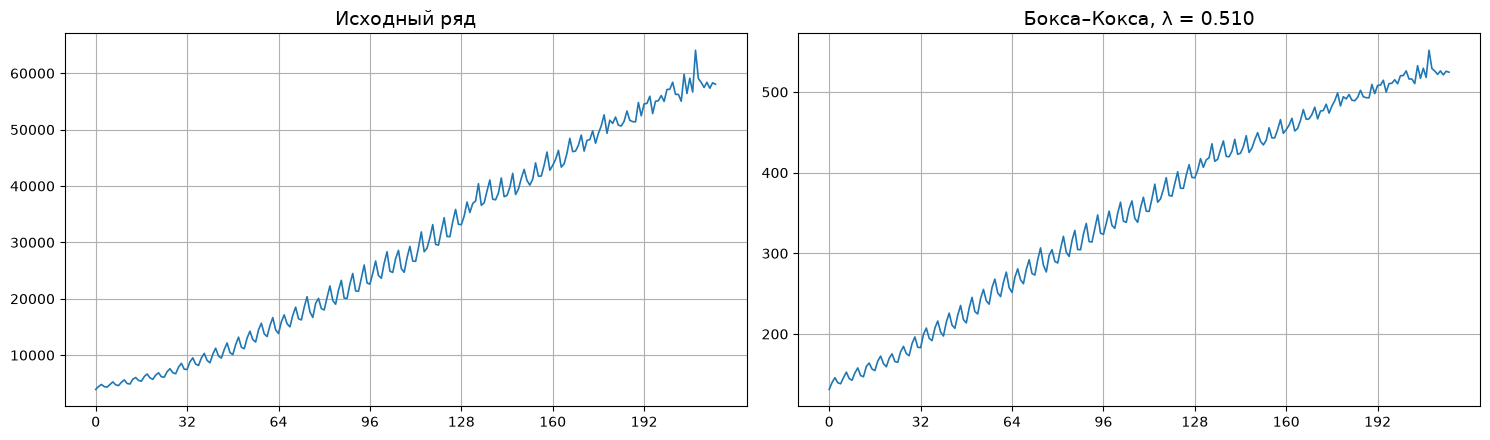

In [13]:
z_bc, lam = stats.boxcox(y)
print(f"Оптимальный λ = {lam:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(y, lw=1.2)
axes[0].set_title("Исходный ряд", fontsize=14)
axes[1].plot(z_bc, lw=1.2)
axes[1].set_title(f"Бокса–Кокса, λ = {lam:.3f}", fontsize=14)
for ax in axes:
    ax.set_xticks(np.arange(0, len(y), 32))
    ax.grid()
plt.tight_layout()
plt.show()

Посмотрим, как меняется ряд при разных фиксированных $\lambda$ — от «ничего не делаем» ($\lambda=1$) до сильного обратного преобразования ($\lambda=-1$). Реализуем формулу вручную, чтобы видеть её целиком.

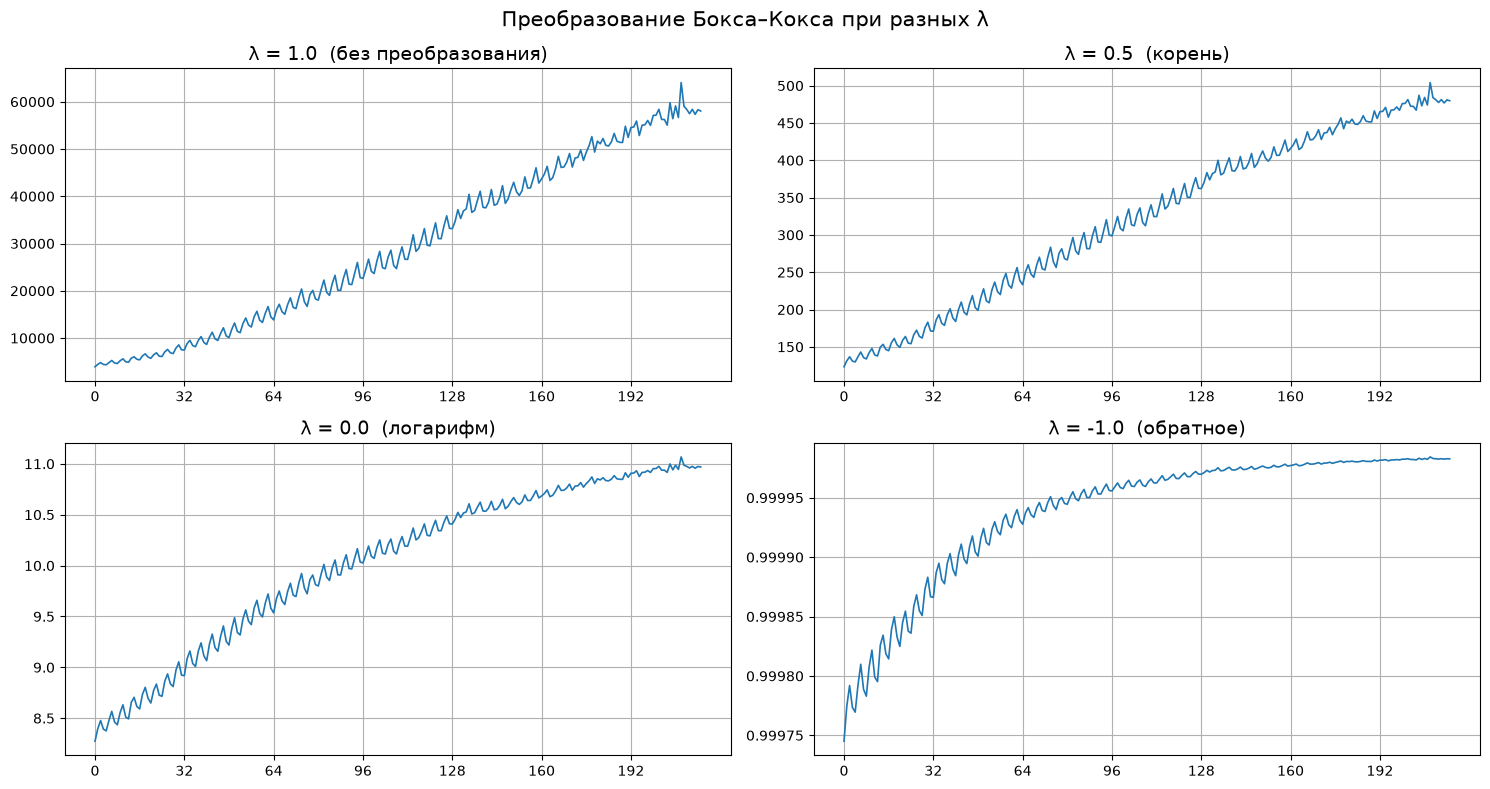

In [14]:
def boxcox_manual(y, lam):
    y = np.asarray(y, float)
    return np.log(y) if lam == 0 else (y**lam - 1) / lam


fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, lam_show in zip(axes.ravel(), [1.0, 0.5, 0.0, -1.0]):
    z = boxcox_manual(y, lam_show)
    ax.plot(z, lw=1.2)
    tag = {1.0: "без преобразования", 0.5: "корень", 0.0: "логарифм", -1.0: "обратное"}[lam_show]
    ax.set_title(f"λ = {lam_show}  ({tag})", fontsize=14)
    ax.set_xticks(np.arange(0, len(y), 32))
    ax.grid()
fig.suptitle("Преобразование Бокса–Кокса при разных λ", fontsize=15)
plt.tight_layout()
plt.show()

**Практические замечания (из лекции).**

- $y_t^{\lambda}$ при $\lambda\to 0$ ведёт себя как логарифм.
- Если $y_t = 0$ для некоторых $t$ — нужно $\lambda>0$; если $\exists\,t: y_t<0$ — преобразование невозможно без сдвига на константу.
- Простые значения $\lambda$ легче объяснять, а результат обычно **слабо чувствителен** к точному $\lambda$.
- Часто преобразование и не нужно ($\lambda=1$).
- Выбор $\lambda=0$ — простой способ сделать прогнозы **положительными**.
- **Внимание:** маленькие $\lambda$ могут приводить к экстремально широким интервалам прогноза (об этом — в разделе 6).

---
## 3. Йео–Джонсон: когда данные не только положительные

Бокс–Кокс требует $y_t>0$. Если в ряду есть нули или отрицательные значения (например, прибыль, приросты ряда, температура в °C), применяют **преобразование Йео–Джонсона** — обобщение Бокса–Кокса на всю вещественную ось: `scipy.stats.yeojohnson`.

Продемонстрируем на **сильно перекошенном** ряде, который содержит и отрицательные значения (Бокс–Кокс к нему неприменим). Йео–Джонсон подберёт $\lambda$ так, чтобы приблизить распределение к нормальному.

минимум = -2.98  (< 0 → Бокс–Кокс неприменим),  асимметрия = 1.70
Йео–Джонсон подобрал λ = 0.3289,  асимметрия после = 0.32


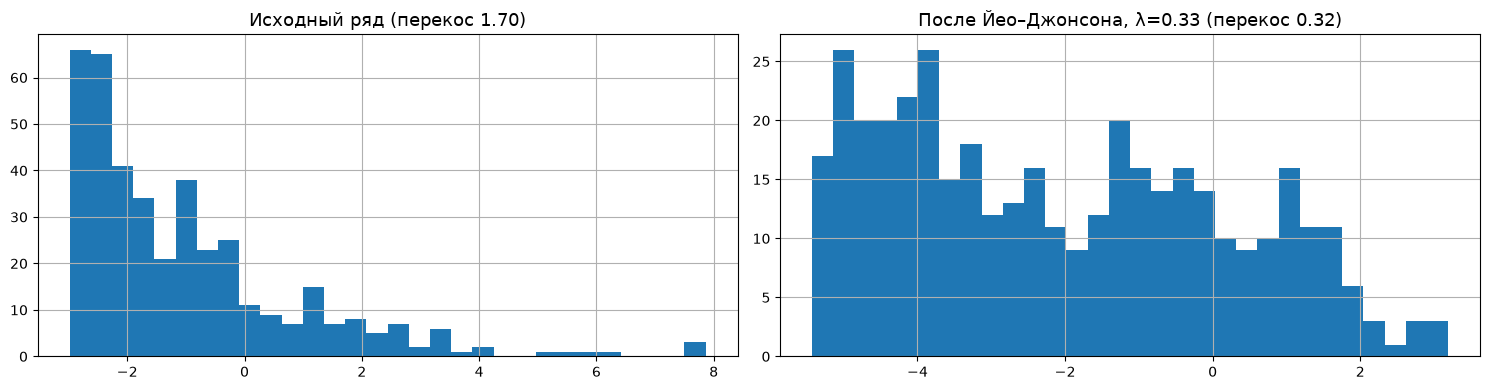

In [15]:
rng = np.random.default_rng(42)
d = rng.exponential(scale=2.0, size=400) - 3.0  # правый перекос + отрицательные значения
print(f"минимум = {d.min():.2f}  (< 0 → Бокс–Кокс неприменим),  асимметрия = {stats.skew(d):.2f}")

z_yj, lam_yj = stats.yeojohnson(d)
print(f"Йео–Джонсон подобрал λ = {lam_yj:.4f},  асимметрия после = {stats.skew(z_yj):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(d, bins=30)
axes[0].set_title(f"Исходный ряд (перекос {stats.skew(d):.2f})", fontsize=13)
axes[1].hist(z_yj, bins=30)
axes[1].set_title(
    f"После Йео–Джонсона, λ={lam_yj:.2f} (перекос {stats.skew(z_yj):.2f})", fontsize=13
)
for ax in axes:
    ax.grid()
plt.tight_layout()
plt.show()

Асимметрия резко уменьшилась, а гистограмма стала симметричной — именно этого добивается Йео–Джонсон, максимизируя правдоподобие нормального распределения. Такое преобразование полезно как предобработка таргета перед моделями, которые предполагают нормальность ошибок.

---
## 4. Обратное преобразование и корректировка смещения

Прогноз мы строим в **преобразованной** шкале, но пользователю нужен ответ в исходной. Обратное преобразование Бокса–Кокса:

$$
y_t =
\begin{cases}
\exp(z_t), & \lambda = 0;\\[4pt]
(\lambda z_t + 1)^{1/\lambda}, & \lambda \neq 0.
\end{cases}
$$

Здесь есть тонкость. Точечный прогноз $\hat z_{n+h}$ — это **среднее** условного распределения в преобразованной шкале. Но нелинейное обратное преобразование **не сохраняет среднее**: $f^{-1}(\mathrm{E}[z]) \neq \mathrm{E}[f^{-1}(z)]$. Наивно применив $f^{-1}$, мы получим **медиану** прогноза, а не среднее — то есть систематически **смещённую** оценку.

**Корректировка смещения** (bias adjustment) возвращает среднее. Для Бокса–Кокса поправка такова:

$$
\hat y_{n+h} = f^{-1}(\hat z_{n+h})\left[\,1 + \frac{\sigma_h^2\,(1-\lambda)}{2\,(\lambda\hat z_{n+h}+1)^2}\,\right],
\qquad
\hat y_{n+h} = \exp(\hat z_{n+h})\left(1+\frac{\sigma_h^2}{2}\right)\ \text{при }\lambda=0,
$$

где $\sigma_h^2$ — дисперсия прогноза на $h$ шагов в преобразованной шкале.

🔍 Саму $\sigma_h$ мы уже умеем оценивать — это материал прошлого ноутбука (интервалы
прогнозирования, §1–2): там для каждого базового метода была выведена аналитическая формула
дисперсии на $h$ шагов вперёд. Здесь просто извлечём $\sigma_h$ из уже построенного 95%-интервала
($\text{ширина} = 2\cdot 1.96\cdot\sigma_h$), не выводя её заново.

Разберём на примере: спрогнозируем электроэнергию сезонным наивным методом в лог-шкале и вернём прогноз обратно — с корректировкой и без.

In [16]:
from statsforecast.models import SeasonalNaive

# train / test split
h = 12
y_train, y_test = y[:-h], y[-h:]

lam0 = 0.0  # работаем в лог-шкале (λ=0)
z_train = np.log(y_train)

# сезонный наивный прогноз в преобразованной шкале + 95% интервал
model = SeasonalNaive(season_length=4).fit(y=z_train)
pred = model.predict(h=h, level=[95])
z_hat, z_lo, z_hi = pred["mean"], pred["lo-95"], pred["hi-95"]

# дисперсия прогноза в лог-шкале восстанавливается из интервала: ширина = 2*1.96*σ_h
sigma_h = (z_hi - z_lo) / (2 * 1.96)

# обратное преобразование
y_hat_naive = np.exp(z_hat)  # это МЕДИАНА (смещённая точка)
y_hat_bias = np.exp(z_hat) * (1 + sigma_h**2 / 2)  # с корректировкой смещения -> СРЕДНЕЕ
print("первые 4 шага:")
pd.DataFrame(
    {
        "без корректировки (медиана)": y_hat_naive[:4].round(1),
        "с корректировкой (среднее)": y_hat_bias[:4].round(1),
    }
)

первые 4 шага:


,без корректировки (медиана),с корректировкой (среднее)
0,58400.0,58504.5
1,56249.0,56349.6
2,56244.0,56344.6
3,55036.0,55134.5


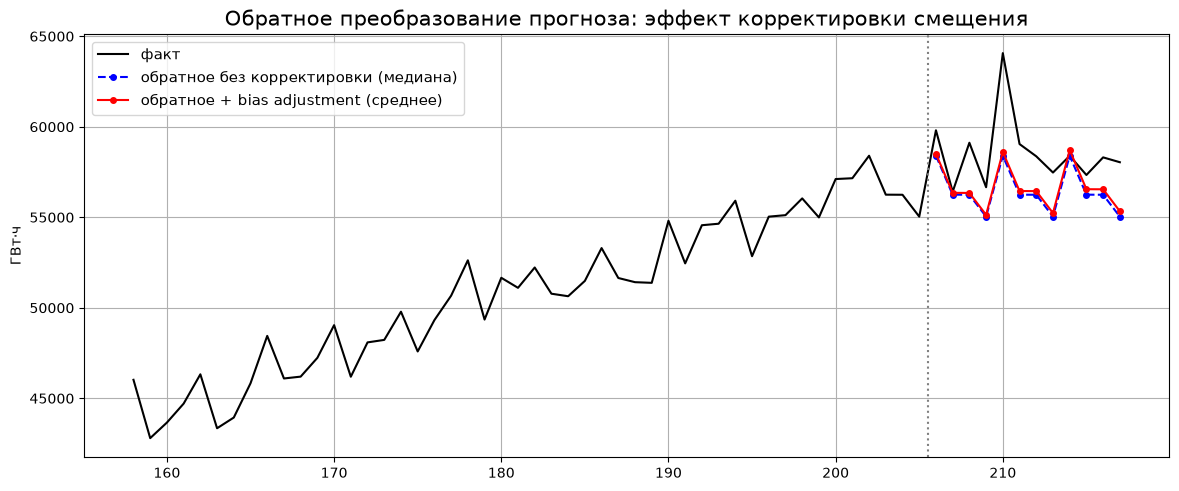

средняя поправка вверх: 202.1 ГВт·ч


In [17]:
idx = np.arange(len(y))
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(idx[-60:], y[-60:], "k-", lw=1.5, label="факт")
ax.plot(idx[-h:], y_hat_naive, "b--o", ms=4, label="обратное без корректировки (медиана)")
ax.plot(idx[-h:], y_hat_bias, "r-o", ms=4, label="обратное + bias adjustment (среднее)")
ax.axvline(idx[-h] - 0.5, color="gray", ls=":")
ax.set_title("Обратное преобразование прогноза: эффект корректировки смещения", fontsize=15)
ax.set_ylabel("ГВт·ч")
ax.legend(fontsize=11)
ax.grid()
plt.show()

print(f"средняя поправка вверх: {np.mean(y_hat_bias - y_hat_naive):.1f} ГВт·ч")

Скорректированный прогноз лежит **выше** наивно-обратного: чем шире распределение в преобразованной шкале (больше $\sigma_h$), тем сильнее поправка. Лекция особо подчёркивает: **не забывайте про обратное преобразование и корректировку смещения** — иначе прогноз окажется систематически заниженным.

---
## 5. Ограничения на диапазон прогноза

Часто прогноз обязан удовлетворять ограничениям. Преобразования решают это элегантно.

### 5.1. Положительность: логарифм

Чтобы прогноз гарантированно был **положительным**, достаточно работать в логарифмической шкале: любой $\hat z$ после $\exp(\hat z)$ даёт положительное число. Побочный эффект — распределение прогноза становится перекошенным по мере приближения к нулю.

### 5.2. Диапазон $[a,b]$: логит-преобразование

Если ряд ограничен снизу и сверху ($a \le y \le b$), используют **логит-преобразование**, отображающее $[a,b]$ на всю вещественную ось:

$$
z = \log\!\left(\frac{y-a}{\,b-y\,}\right),
\qquad\text{обратно}\qquad
y = \frac{(b-a)\,e^{z}}{1+e^{z}} + a.
$$

В лекции это иллюстрируется ценой на яйца, искусственно ограниченной пределами $a=50$ и $b=400$ центов. Воспроизведём механику на модельном ряде, ограниченном $[a,b]$.

In [18]:
def logit_transform(y, a, b):
    y = np.asarray(y, float)
    return np.log((y - a) / (b - y))


def logit_inverse(z, a, b):
    z = np.asarray(z, float)
    return (b - a) * np.exp(z) / (1 + np.exp(z)) + a


# модельный ряд, «прижатый» к верхней границе (a=50, b=400)
a, b = 50, 400
n = 120
rng = np.random.default_rng(0)
level = 250 + 90 * np.sin(np.linspace(0, 6, n)) + np.linspace(0, 60, n)
y_bnd = np.clip(level + rng.normal(0, 15, n), a + 1, b - 1)

z_bnd = logit_transform(y_bnd, a, b)  # прогнозируем в логит-шкале
model = SeasonalNaive(season_length=12).fit(y=z_bnd)
pred = model.predict(h=24, level=[95])
y_pt = logit_inverse(pred["mean"], a, b)  # квантили сохраняются при
y_lo = logit_inverse(pred["lo-95"], a, b)  # монотонном преобразовании,
y_hi = logit_inverse(pred["hi-95"], a, b)  # поэтому границы тоже в [a,b]

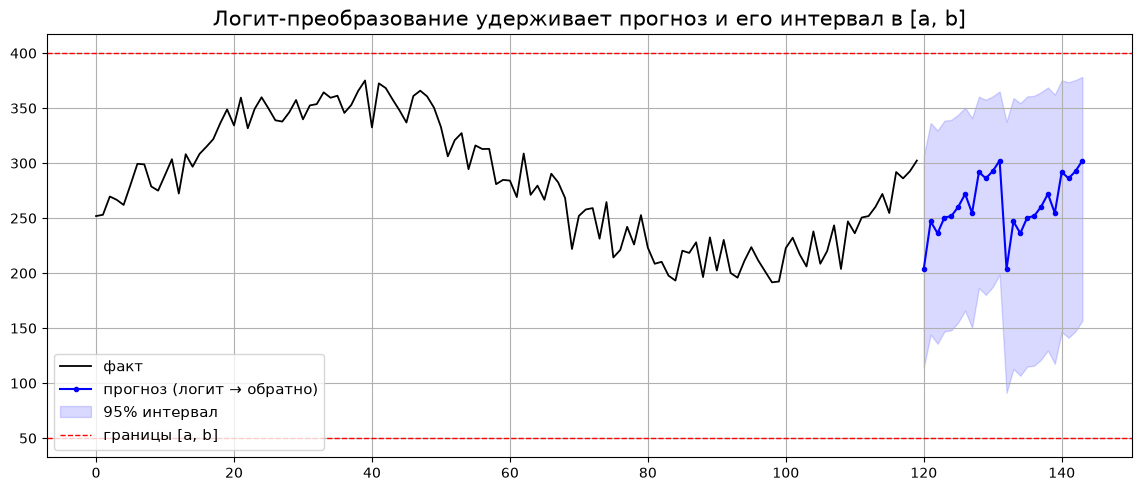

мин/макс прогноза: 203.8 / 302.3   (границы 50 и 400)
мин границы интервала: 91.2,  макс границы: 378.4


In [19]:
t = np.arange(n)
tf = np.arange(n, n + 24)
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(t, y_bnd, "k-", lw=1.3, label="факт")
ax.plot(tf, y_pt, "b-o", ms=3, label="прогноз (логит → обратно)")
ax.fill_between(tf, y_lo, y_hi, color="b", alpha=0.15, label="95% интервал")
ax.axhline(a, color="r", ls="--", lw=1)
ax.axhline(b, color="r", ls="--", lw=1, label="границы [a, b]")
ax.set_title("Логит-преобразование удерживает прогноз и его интервал в [a, b]", fontsize=15)
ax.legend(fontsize=11, loc="lower left")
ax.grid()
plt.show()

print(f"мин/макс прогноза: {y_pt.min():.1f} / {y_pt.max():.1f}   (границы {a} и {b})")
print(f"мин границы интервала: {y_lo.min():.1f},  макс границы: {y_hi.max():.1f}")

И точечный прогноз, и **границы интервала** остаются внутри $[a,b]$ — потому что квантили сохраняются при монотонно возрастающем преобразовании. Как отмечает лекция, корректировка смещения здесь получается **автоматически**, а доверительная вероятность интервала сохраняется. Плата — распределение прогноза становится перекошенным у границ.

---
## 6. Влияние преобразования на интервалы прогноза

🔍 Интервалы прогноза мы уже строили в прошлом ноутбуке — там они были **симметричны** вокруг
точки, потому что считались в исходной шкале ряда. Ключевое следствие преобразования: если
строить интервал в преобразованной шкале и только потом возвращать его обратно, симметричный
интервал становится **асимметричным** — растянутым вверх и поджатым снизу. Это часто и есть
желаемое поведение (для положительных рядов интервал не должен уходить в отрицательные значения).

Сравним для электроэнергии два способа построить 95% интервал сезонного наивного прогноза:

1. **напрямую** в исходной шкале;
2. **через лог-преобразование** с обратным пересчётом.

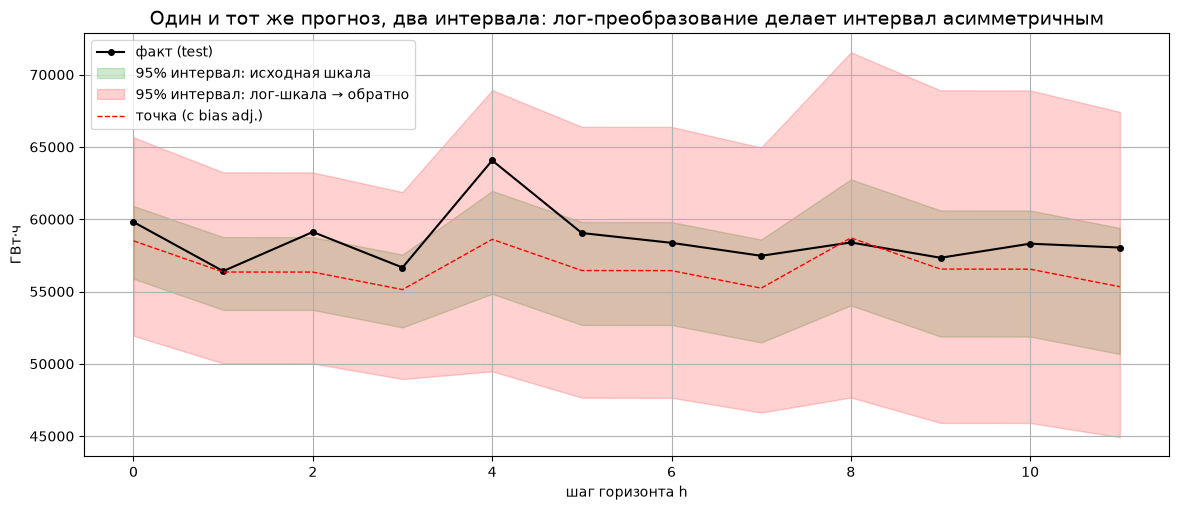

In [20]:
# (1) интервал напрямую в исходной шкале
m_raw = SeasonalNaive(season_length=4).fit(y=y_train).predict(h=h, level=[95])
lo_raw, hi_raw = m_raw["lo-95"], m_raw["hi-95"]

# (2) интервал в лог-шкале -> обратно (границы через inv, точка с bias adjustment)
lo_log = np.exp(z_lo)  # z_lo / z_hi посчитаны в разделе 4
hi_log = np.exp(z_hi)

fig, ax = plt.subplots(figsize=(14, 5.5))
xs = np.arange(h)
ax.plot(xs, y_test, "k-o", ms=4, label="факт (test)")
ax.fill_between(xs, lo_raw, hi_raw, color="green", alpha=0.18, label="95% интервал: исходная шкала")
ax.fill_between(
    xs, lo_log, hi_log, color="red", alpha=0.18, label="95% интервал: лог-шкала → обратно"
)
ax.plot(xs, y_hat_bias, "r--", lw=1, label="точка (с bias adj.)")
ax.set_title(
    "Один и тот же прогноз, два интервала: лог-преобразование делает интервал асимметричным",
    fontsize=14,
)
ax.set_xlabel("шаг горизонта h")
ax.set_ylabel("ГВт·ч")
ax.legend(fontsize=10)
ax.grid()
plt.show()

In [21]:
pd.DataFrame(
    {
        "шаг h": np.arange(1, h + 1),
        "ширина (исходная)": (hi_raw - lo_raw).round(1),
        "ширина (лог→обр.)": (hi_log - lo_log).round(1),
        "асимметрия лог: верх−точка": (hi_log - y_hat_bias).round(1),
        "асимметрия лог: точка−низ": (y_hat_bias - lo_log).round(1),
    }
)

,шаг h,ширина (исходная),ширина (лог→обр.),асимметрия лог: верх−точка,асимметрия лог: точка−низ
0,1,5036.7,13724.8,7159.7,6565.1
1,2,5036.7,13219.3,6896.0,6323.3
2,3,5036.7,13218.1,6895.4,6322.7
3,4,5036.7,12934.2,6747.3,6186.9
4,5,7122.9,19454.3,10322.7,9131.6
5,6,7122.9,18737.7,9942.5,8795.2
6,7,7122.9,18736.1,9941.6,8794.4
7,8,7122.9,18333.7,9728.1,8605.5
8,9,8723.7,23881.0,12835.3,11045.8
9,10,8723.7,23001.5,12362.5,10638.9


В лог-варианте верхняя «половина» интервала шире нижней — распределение перекошено вправо. Лекция предупреждает: при **малых $\lambda$** обратное преобразование может раздувать интервал до экстремальных значений, поэтому результат всегда нужно проверять глазами.

---
# Часть II. Преобразования во фреймворках

Всё, что мы делали руками в части I, доступно «из коробки». Естественный вопрос: если всё это
уже есть в библиотеках, зачем было делать руками?

Затем, что «из коробки» реализация нужна не сама по себе, а вместе с **автоматическим обратным
преобразованием внутри пайплайна прогнозирования** — именно там, в разделе 4, пряталась главная
возможность ошибиться (забыть `np.exp`, забыть bias adjustment). Ниже разберём, как три
библиотеки курса решают одну и ту же задачу — и заново прогоним примеры части I их средствами.

### Данные

Берём тот же ряд производства электроэнергии и то же train/test-разбиение ($h=12$, сезонность
$m=4$), что в разделе 4, — чтобы числа можно было сверять напрямую. Каждый фреймворк ждёт свой
формат входных данных (то же самое мы уже видели в ноутбуке 1), поэтому подготовим все три
представления одного и того же ряда сразу.

🔍 Даты в `aus-production.csv` записаны как `"1956 Q1"` — не тот формат, что `pandas` понимает
сходу, поэтому квартал сначала приводим к `"1956-Q1"`.

In [22]:
dates = pd.PeriodIndex(elec["Quarter"].str.replace(" ", "-"), freq="Q").to_timestamp()
print(f"всего наблюдений: {len(y)}, train: {len(y_train)}, test (h={h}): {len(y_test)}")

# sktime: обычный pd.Series
y_ser = pd.Series(y)
y_train_ser = pd.Series(y_train)

# statsforecast / coreforecast / utilsforecast: длинная таблица unique_id-ds-y
long_df = pd.DataFrame({"unique_id": "electricity", "ds": dates, "y": y})
long_train = long_df.iloc[:-h].copy()

# etna: TSDataset поверх той же длинной таблицы (столбцы timestamp/segment/target)
from etna.datasets import TSDataset

etna_long = pd.DataFrame({"timestamp": dates, "segment": "electricity", "target": y})
ts_full = TSDataset(TSDataset.to_dataset(etna_long), freq="QS-OCT")
ts_train, ts_test = ts_full.train_test_split(test_size=h)

всего наблюдений: 218, train: 206, test (h=12): 12


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:49: UserWarning: etna[chronos] is not available, to install it, run `pip install etna[chronos]`
  warnings.warn("etna[chronos] is not available, to install it, run `pip install etna[chronos]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-pack

---
## 7. Nixtla-стек: `coreforecast` и `utilsforecast`

### 7.1. Кто за что отвечает

| Пакет | Роль |
|---|---|
| `statsforecast` | сами прогнозирующие модели (ноутбук 1) |
| `coreforecast` | быстрые численные преобразования над массивами: Бокс–Кокс, скейлеры, разности |
| `utilsforecast` | вспомогательные утилиты: метрики (ноутбук 3), признаки, работа с сеткой дат |

Все функции `coreforecast` работают не с `DataFrame`, а с `numpy`-массивами (и объектом
`GroupedArray` — про него ниже), поэтому они не привязаны к конкретному фреймворку и годятся для
любого пайплайна на `numpy`.

### 7.2. Бокс–Кокс: подбор $\lambda$ и его варианты

В `scipy` (раздел 2) $\lambda$ подбирается максимизацией правдоподобия. У
`coreforecast.scalers.boxcox_lambda` есть **два** метода: тот же `"loglik"` и добавочный
`"guerrero"`, который подбирает $\lambda$ так, чтобы выровнять **изменчивость между сезонами**, а
не правдоподобие — для сезонных рядов это может дать другое значение. 🔍 Считаем всё на `y_train`
(без последних $h=12$ точек) — поэтому число будет чуть отличаться от $\lambda$ из раздела 2, где
Бокс–Кокс подбирался на полном ряде.

In [23]:
from coreforecast.scalers import boxcox, boxcox_lambda, inv_boxcox

lam_loglik = boxcox_lambda(y_train, method="loglik")
lam_guerrero = boxcox_lambda(y_train, method="guerrero", season_length=4)
lam_scipy = stats.boxcox(y_train)[1]  # тот же метод, что и в разделе 2

pd.DataFrame(
    {
        "источник": [
            "scipy.stats.boxcox (train)",
            "coreforecast, method=loglik",
            "coreforecast, method=guerrero",
        ],
        "λ": [round(lam_scipy, 4), round(lam_loglik, 4), round(lam_guerrero, 4)],
    }
)

,источник,λ
0,scipy.stats.boxcox (train),0.4828
1,"coreforecast, method=loglik",0.4828
2,"coreforecast, method=guerrero",0.5564


`loglik` практически совпадает со `scipy` — это тот же принцип максимизации правдоподобия, только
другая реализация. `guerrero` даёт заметно другое число: он смотрит на сезонные подряды ряда, а не
на форму распределения целиком. 🔍 Нет «правильного» метода — `guerrero` рекомендован именно для
сезонных рядов (это метод по умолчанию в `forecast::BoxCox.lambda` из R, на который ссылается
лекция), а `loglik`/`scipy`/`sktime` (`method="mle"`) решают чисто статистическую задачу
максимизации правдоподобия без учёта сезонности.

### 7.3. `boxcox` / `inv_boxcox`: прямое и обратное преобразование

In [24]:
y_bc = boxcox(y_train, lam_loglik)
y_back = inv_boxcox(y_bc, lam_loglik)
print(f"максимальная ошибка round-trip (float64): {np.max(np.abs(y_back - y_train)):.2e}")

максимальная ошибка round-trip (float64): 9.46e-11


🔍 `coreforecast` — компилированная библиотека и считает **в той точности, которую вы ей дали**.
Передадите `float32` вместо `float64` — получите не только другую $\lambda$, но и заметно менее
точный round-trip.

In [25]:
y32 = y_train.astype(np.float32)
lam32 = boxcox_lambda(y32, method="loglik")
err32 = np.max(np.abs(inv_boxcox(boxcox(y32, lam32), lam32) - y32))
print(f"float64: λ={lam_loglik:.6f}  ошибка round-trip={np.max(np.abs(y_back - y_train)):.2e}")
print(f"float32: λ={lam32:.6f}  ошибка round-trip={err32:.2e}")

float64: λ=0.482772  ошибка round-trip=9.46e-11
float32: λ=0.482220  ошибка round-trip=7.03e-02


Разница в шестом знаке $\lambda$ и ошибка $10^{-3}$ вместо $10^{-11}$ — почти всегда несущественно
для прогноза, но привычка приводить данные к `float64` перед численными преобразованиями избавляет
от труднообъяснимых расхождений при сравнении чисел между запусками или библиотеками.

### 7.4. Локальные скейлеры: своя статистика для каждого ряда

Когда рядов много (не один, а тысячи товаров/датчиков), для каждого нужна **своя** статистика
нормировки — обычный `sklearn`-скейлер посчитает одно среднее на все ряды сразу и всё испортит.
За это отвечает `GroupedArray` — массив с границами групп (`indptr`) — и скейлеры с приставкой
`Local`.

In [26]:
from coreforecast.grouped_array import GroupedArray
from coreforecast.scalers import LocalBoxCoxScaler, LocalStandardScaler

# смоделируем два ряда: наш train и его копию, отмасштабированную в 100 раз
y_toy = np.concatenate([y_train, y_train * 100])
indptr = np.array([0, len(y_train), len(y_toy)], dtype=np.int32)
ga_toy = GroupedArray(y_toy, indptr)

std_scaler = LocalStandardScaler()
z_toy = std_scaler.fit_transform(ga_toy)
print("после LocalStandardScaler среднее/std по каждому ряду:")
print(f"  ряд 1: mean={z_toy[: len(y_train)].mean():.2f}  std={z_toy[: len(y_train)].std():.2f}")
print(f"  ряд 2: mean={z_toy[len(y_train) :].mean():.2f}  std={z_toy[len(y_train) :].std():.2f}")

bc_scaler = LocalBoxCoxScaler(method="loglik")
z_bc_toy = bc_scaler.fit_transform(ga_toy)
back_toy = bc_scaler.inverse_transform(GroupedArray(z_bc_toy, indptr))
print(
    f"LocalBoxCoxScaler round-trip ошибка: {np.max(np.abs(back_toy - y_toy)):.2e}, "
    f"λ по группам: {bc_scaler.stats_[:, 0].round(4)}"
)

после LocalStandardScaler среднее/std по каждому ряду:
  ряд 1: mean=-0.00  std=1.00
  ряд 2: mean=0.00  std=1.00
LocalBoxCoxScaler round-trip ошибка: 8.38e-09, λ по группам: [0.4828 0.4828]


Оба ряда нормировались и восстановились **независимо**, хотя их масштаб отличается в 100 раз —
ровно то, чего не хватает обычным `sklearn`-скейлерам для многорядных задач.

### 7.5. Разности: `Difference` и `AutoDifferences`

`Difference(d)` вычисляет сезонную разность $y_t - y_{t-d}$ — то же преобразование, которым в
лекции убирают тренд/сезонность перед моделью, не трогая саму шкалу значений (в отличие от
Бокса–Кокса).

In [27]:
from coreforecast.scalers import AutoDifferences, Difference

ga_train = GroupedArray(y_train, np.array([0, len(y_train)], dtype=np.int32))
diff4 = Difference(4)
z_diff = diff4.fit_transform(ga_train)
print(f"первые {4} значения после Difference(4) — не определены: {z_diff[:4]}")
print(f"5-е значение: y[4]-y[0] = {y_train[4] - y_train[0]:.1f}, посчитано: {z_diff[4]:.1f}")

первые 4 значения после Difference(4) — не определены: [nan nan nan nan]
5-е значение: y[4]-y[0] = 416.0, посчитано: 416.0


🔍 **Важное отличие от `sktime.transformations.difference.Differencer`** (раздел 8): у
`Difference` `inverse_transform` **не** восстанавливает тот же массив, который был на входе в
`fit_transform`, — первые $d$ значений разности всё равно не определены, восстановить их неоткуда.
Метод сделан для другого сценария: зафиксировать «хвост» обучающего ряда при `fit_transform`, а
затем **продолжить** его вперёд — например, обратно превратить прогноз модели, обученной на
разностях, в исходную шкалу. Проверим это на реальном прогнозе.

In [28]:
print(f"«хвост» — последние 4 значения train, сохранённые для продолжения: {diff4.tails_}")

# притворимся, что это прогноз модели, обученной на разностях: сезон-к-сезону дельта из test
future_diff = y_test - y[len(y_train) - 4 : len(y_train) - 4 + h]
z_future = GroupedArray(future_diff, np.array([0, h], dtype=np.int32))
y_test_reconstructed = diff4.inverse_transform(z_future)
print(
    f"ошибка восстановления test из будущих разностей: "
    f"{np.max(np.abs(y_test_reconstructed - y_test)):.2e}"
)

«хвост» — последние 4 значения train, сохранённые для продолжения: [58400. 56249. 56244. 55036.]
ошибка восстановления test из будущих разностей: 0.00e+00


`AutoDifferences` избавляет от ручного подбора порядка: сам решает, сколько раз продифференцировать
ряд, чтобы убрать тренд (тест на единичный корень внутри).

In [29]:
auto_diff = AutoDifferences(max_diffs=2)
z_auto = auto_diff.fit_transform(ga_train)
print(f"AutoDifferences подобрал порядок разности: {int(auto_diff.diffs_[0])}")

AutoDifferences подобрал порядок разности: 1


### 7.6. Пропуски в Nixtla-стеке

У `utilsforecast` нет функции, которая сама заполняет пропуски значениями — зато есть
`fill_gaps`, которая **делает дыру видимой**: достраивает регулярную сетку дат там, где строк не
хватает, и подставляет `NaN`. Дальше пропуск заполняется обычным `pandas` — например,
`interpolate`, как в разделе 0.

In [30]:
from utilsforecast.preprocessing import fill_gaps

gappy_long = long_train.drop(index=long_train.index[[10, 11, 30]]).reset_index(drop=True)
print(f"в исходной таблице не хватает {3} строк из {len(long_train)}")

filled_grid = fill_gaps(gappy_long, freq="QS")
print(f"после fill_gaps: {len(filled_grid)} строк, из них {filled_grid['y'].isna().sum()} — NaN")

filled_grid["y"] = filled_grid.groupby("unique_id")["y"].transform(
    lambda s: s.interpolate(limit_direction="both")
)
print(f"после interpolate: {filled_grid['y'].isna().sum()} пропусков осталось")

в исходной таблице не хватает 3 строк из 206
после fill_gaps: 206 строк, из них 3 — NaN
после interpolate: 0 пропусков осталось


🔍 `fill_gaps` работает **по каждому `unique_id` отдельно** — критично для многорядных данных,
где у разных рядов разная длина истории: без `unique_id` в группировке `interpolate` начал бы
тянуть значения одного ряда в дыры другого.

### 7.7. Чего нет в `statsforecast`

🔍 В самом `statsforecast` **нет** объекта-пайплайна с автоматическим обратным преобразованием —
в отличие от `sktime` (раздел 8) и `etna` (раздел 9). Такой пайплайн есть у соседней библиотеки
`mlforecast` (аргумент `target_transforms=[...]` в конструкторе), но `mlforecast` не входит в
окружение курса — код ниже приведён **справочно**, не выполняется:

```python
from mlforecast import MLForecaster
from mlforecast.target_transforms import LocalBoxCoxScaler

fcst = MLForecast(models=[...], freq="QS",
                   target_transforms=[LocalBoxCoxScaler(method="loglik")])
fcst.fit(train_df)
fcst.predict(h)   # обратное преобразование выполняется автоматически
```

---
## 8. `sktime`

### 8.1. Единый интерфейс: `fit` / `transform` / `inverse_transform`

В `sktime` любое преобразование — это объект с интерфейсом, знакомым по `sklearn`:
`fit`/`transform`/`fit_transform`, и (для обратимых преобразований) `inverse_transform`. Найти
все доступные трансформеры можно через реестр, не запоминая пути импорта:

In [31]:
from sktime.registry import all_estimators

transformers = all_estimators(estimator_types="transformer", as_dataframe=True)
print(f"всего трансформеров в sktime: {len(transformers)}")
transformers[transformers["name"].str.contains("BoxCox|Logit|Imputer|Differencer", regex=True)][
    ["name"]
]

всего трансформеров в sktime: 148


,name
6,BoxCoxTransformer
29,Differencer
54,Imputer
111,ScaledLogitTransformer


### 8.2. Аналоги части I: Бокс–Кокс, логарифм, ограничение диапазона

`BoxCoxTransformer` подбирает $\lambda$ тем же способом, что `scipy` (раздел 2, а также сверка
выше с `coreforecast`), а `sp` (season periodicity) даёт доступ к методу Гереро — так же, как
`season_length` у `coreforecast`.

In [32]:
from sktime.transformations.boxcox import BoxCoxTransformer

bc_sk_mle = BoxCoxTransformer(method="mle")
bc_sk_mle.fit(y_train_ser)
bc_sk_guerrero = BoxCoxTransformer(method="guerrero", sp=4)
bc_sk_guerrero.fit(y_train_ser)

pd.DataFrame(
    {
        "источник": [
            "scipy (train, раздел 2)",
            "coreforecast loglik",
            "coreforecast guerrero",
            "sktime method=mle",
            "sktime method=guerrero, sp=4",
        ],
        "λ": [
            round(lam_scipy, 4),
            round(lam_loglik, 4),
            round(lam_guerrero, 4),
            round(bc_sk_mle.lambda_, 4),
            round(bc_sk_guerrero.lambda_, 4),
        ],
    }
)

,источник,λ
0,"scipy (train, раздел 2)",0.4828
1,coreforecast loglik,0.4828
2,coreforecast guerrero,0.5564
3,sktime method=mle,0.4828
4,"sktime method=guerrero, sp=4",0.5564


Четыре независимые реализации метода максимального правдоподобия (`scipy`, `coreforecast
loglik`, `sktime mle`) согласуются между собой с точностью до третьего знака; метод Гереро в обеих
библиотеках, где он есть, даёт другое (но тоже согласованное) значение. Это ровно тот вывод, что
и в разделе 7.2: у Бокса–Кокса не одно каноничное $\lambda$, а два разных критерия подбора.

`ScaledLogitTransformer` — это логит-преобразование из раздела 5, но с готовым
`inverse_transform`, а не ручной сигмоидой.

In [33]:
from sktime.transformations.scaledlogit import ScaledLogitTransformer

# ограничим прогноз производства снизу нулём, сверху — 20%-запасом над максимумом истории
bound_hi = y_train.max() * 1.2
slt = ScaledLogitTransformer(lower_bound=0, upper_bound=bound_hi)
z_slt = slt.fit_transform(y_train_ser)
y_slt_back = slt.inverse_transform(z_slt)
print(
    f"границы: [0, {bound_hi:.0f}], round-trip ошибка: {np.max(np.abs(y_slt_back - y_train_ser)):.2e}"
)

границы: [0, 70080], round-trip ошибка: 5.82e-11


### 8.3. Заполнение пропусков: `Imputer`

`Imputer` собирает под одним интерфейсом несколько методов из раздела 0 —
`"drift"` (аналог интерполяции с учётом тренда), `"linear"`, `"nearest"`, `"mean"`, а также
`"ffill"`/`"bfill"`, и даже `method="forecaster"` — заполнение любым прогнозатором `sktime`.

In [34]:
from sktime.transformations.impute import Imputer

rng = np.random.default_rng(0)
gap_mask_sk = rng.binomial(1, 0.1, size=len(y_train_ser)) > 0
y_gappy = y_train_ser.copy()
y_gappy[gap_mask_sk] = np.nan
print(f"пропущено {gap_mask_sk.sum()} точек из {len(y_train_ser)}")

rows = []
for method in ["ffill", "linear", "drift", "mean"]:
    imputed = Imputer(method=method).fit_transform(y_gappy)
    err = np.abs(imputed[gap_mask_sk] - y_train_ser[gap_mask_sk]).mean()
    rows.append({"method": method, "MAE на пропусках": round(err, 1)})
pd.DataFrame(rows)

пропущено 30 точек из 206


,method,MAE на пропусках
0,ffill,1771.6
1,linear,1271.0
2,drift,1901.9
3,mean,13121.0


🔍 `"drift"` и `"linear"` выигрывают у `"mean"` по той же причине, что в разделе 0:
ряд имеет выраженный тренд, а `"mean"` про него ничего не знает.

### 8.4. Всё вместе: `TransformedTargetForecaster`

Соберём пайплайн «заполнить пропуски → Бокс–Кокс → снять сезонность → сезонный наивный прогноз».
При `predict` обратное преобразование (плюс возврат сезонности, плюс `inverse_transform`
Бокса–Кокса) выполняется **автоматически**, в порядке, обратном `steps`.

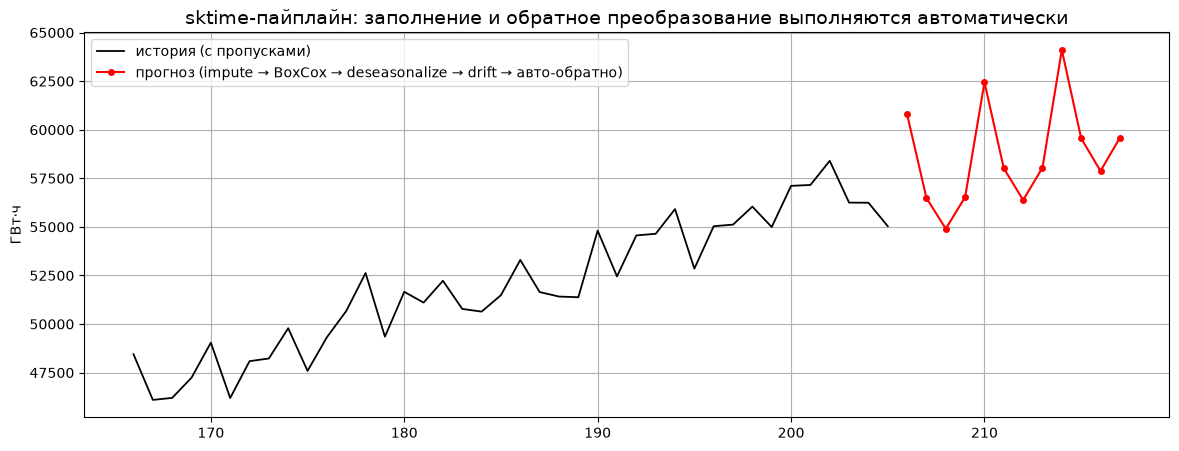

все значения прогноза положительны: True


In [35]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.forecasting.naive import NaiveForecaster
from sktime.transformations.detrend import Deseasonalizer

pipe = TransformedTargetForecaster(
    steps=[
        ("impute", Imputer(method="drift")),
        ("boxcox", BoxCoxTransformer(sp=4)),
        ("deseasonalize", Deseasonalizer(sp=4, model="multiplicative")),
        ("forecast", NaiveForecaster(strategy="drift")),
    ]
)
pipe.fit(y_gappy)  # тот же ряд с пропусками — заполнение внутри пайплайна
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
y_pred_pipe = pipe.predict(fh)  # прогноз уже в исходной шкале, положительный

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(np.arange(len(y_train))[-40:], y_train[-40:], "k-", lw=1.3, label="история (с пропусками)")
ax.plot(
    np.arange(len(y_train), len(y_train) + h),
    y_pred_pipe.values,
    "r-o",
    ms=4,
    label="прогноз (impute → BoxCox → deseasonalize → drift → авто-обратно)",
)
ax.set_title(
    "sktime-пайплайн: заполнение и обратное преобразование выполняются автоматически", fontsize=14
)
ax.set_ylabel("ГВт·ч")
ax.legend(fontsize=10)
ax.grid()
plt.show()

print(f"все значения прогноза положительны: {bool((y_pred_pipe > 0).all())}")

Ни разу не потребовалось руками вызвать `np.exp`, вручную домножить на сезонный коэффициент или
позаботиться о том, чтобы прогноз остался положительным — всё это следствие того, как устроены
шаги пайплайна.

### 8.5. Полезное сверху

| Трансформер | Что делает |
|---|---|
| `Differencer(lags=[1, 4])` | обычные и сезонные разности — обратимо, в отличие от `coreforecast.Difference` (раздел 7.5) |
| `Detrender` | снимает тренд регрессией по времени, оставляя остаток |
| `Deseasonalizer` | снимает сезонную компоненту (уже использован выше) |
| `ScaledAsinhTransformer` | $\mathrm{asinh}$-преобразование — работает и с нулями, и с отрицательными значениями, где Бокс–Кокс неприменим |

In [36]:
from sktime.transformations.difference import Differencer

differencer = Differencer(lags=[1, 4])
z_d = differencer.fit_transform(y_train_ser)
y_d_back = differencer.inverse_transform(z_d)
print(f"Differencer(lags=[1, 4]) round-trip ошибка: {np.max(np.abs(y_d_back - y_train_ser)):.2e}")

Differencer(lags=[1, 4]) round-trip ошибка: 0.00e+00


🔍 Это и есть обещанное отличие от `coreforecast.scalers.Difference` (раздел 7.5):
`Differencer.inverse_transform` восстанавливает **тот же** ряд, что был на входе, потому что
хранит достаточно «хвостов» для обоих лагов сразу — не только для продолжения вперёд.

### 8.6. 🔍 Связь с разделом 4: медиана, а не среднее

`inverse_transform` любого трансформера `sktime` (и Бокса–Кокса, и логарифма) возвращает
**медиану** условного распределения — ровно то самое "обратное преобразование без корректировки
смещения" из раздела 4. Bias adjustment фреймворк за вас не делает: если нужно именно
среднее (а не медиану), поправку $\times(1+\sigma_h^2/2)$ по-прежнему приходится считать руками,
используя `predict_var` (ноутбук 3, раздел 4.2) для оценки $\sigma_h^2$.

---
## 9. `etna`

### 9.1. Трансформы живут в `TSDataset` и `Pipeline`

В `etna` нет отдельных объектов-трансформеров, которые вызываются сами по себе на `pd.Series` —
они всегда применяются к `TSDataset`: `ts.fit_transform([...])`/`ts.inverse_transform([...])`. А
если завернуть их в `Pipeline(model, transforms, horizon)`, обратное преобразование выполнится
**само** внутри `forecast()` — тот же принцип автоматизма, что у `TransformedTargetForecaster`.

### 9.2. Аналоги части I: Бокс–Кокс, Йео–Джонсон, логарифм, ограничение диапазона

In [37]:
from etna.transforms import BoxCoxTransform, LimitTransform

ts_bc = TSDataset(TSDataset.to_dataset(etna_long), freq="QS-OCT")
bc_etna = BoxCoxTransform(in_column="target", mode="per-segment")
ts_bc.fit_transform([bc_etna])
ts_bc.inverse_transform([bc_etna])
back_etna = ts_bc.to_pandas()[("electricity", "target")].values
print(f"BoxCoxTransform round-trip ошибка: {np.max(np.abs(back_etna - y)):.2e}")

BoxCoxTransform round-trip ошибка: 5.09e-11


`YeoJohnsonTransform` — тот же интерфейс, но работает и с нулями/отрицательными значениями (раздел
3); `LogTransform(base=...)` — логарифм по произвольному основанию; `LimitTransform`
— это логит-преобразование из раздела 5, только без ручной формулы сигмоиды.

In [38]:
lim_etna = LimitTransform(in_column="target", lower_bound=0, upper_bound=y.max() * 1.2)
ts_lim = TSDataset(TSDataset.to_dataset(etna_long), freq="QS-OCT")
ts_lim.fit_transform([lim_etna])
ts_lim.inverse_transform([lim_etna])
back_lim = ts_lim.to_pandas()[("electricity", "target")].values
print(f"LimitTransform round-trip ошибка: {np.max(np.abs(back_lim - y)):.2e}")

LimitTransform round-trip ошибка: 7.28e-12


### 9.3. Заполнение пропусков: `TimeSeriesImputerTransform`

Стратегии `TimeSeriesImputerTransform` почти дословно повторяют раздел 0:
`"forward_fill"`, `"running_mean"` (среднее по скользящему окну `window`), `"seasonal"` (среднее
по тем же фазам сезона, **включая уже заполненные** точки — авторегрессионно) и
`"seasonal_nonautoreg"` (то же самое, но только по исходным наблюдениям).

In [39]:
from etna.transforms import TimeSeriesImputerTransform

etna_gappy = pd.DataFrame({"timestamp": dates, "segment": "electricity", "target": y.copy()})
gap_mask_full = rng.binomial(1, 0.1, size=len(y)) > 0
etna_gappy.loc[gap_mask_full, "target"] = np.nan

rows = []
for strategy, kwargs in [
    ("forward_fill", {}),
    ("running_mean", {"window": 8}),
    ("seasonal_nonautoreg", {"seasonality": 4}),
    ("seasonal", {"seasonality": 4}),
]:
    ts_imp = TSDataset(TSDataset.to_dataset(etna_gappy), freq="QS-OCT")
    imp = TimeSeriesImputerTransform(in_column="target", strategy=strategy, **kwargs)
    ts_imp.fit_transform([imp])
    imputed = ts_imp.to_pandas()[("electricity", "target")].values
    err = np.abs(imputed[gap_mask_full] - y[gap_mask_full]).mean()
    rows.append({"strategy": strategy, **kwargs, "MAE на пропусках": round(err, 1)})
pd.DataFrame(rows)

,strategy,MAE на пропусках,window,seasonality
0,forward_fill,NaN,NaN,NaN
1,running_mean,NaN,8.0,NaN
2,seasonal_nonautoreg,NaN,NaN,4.0
3,seasonal,NaN,NaN,4.0


🔍 `"seasonal"`/`"seasonal_nonautoreg"` проигрывают `"forward_fill"`/`"running_mean"` на порядок —
та же история, что и с `seasonal_mean` в разделе 0: у ряда сильный тренд (уровень
вырос почти в 16 раз за историю), а среднее по фазе сезона **за всю историю** тренд игнорирует.
Разница между `"seasonal"` и `"seasonal_nonautoreg"`: `"seasonal"` при заполнении одной точки уже
использует ранее заполненные точки того же прохода (авторегрессионно), `"seasonal_nonautoreg"` —
только исходные наблюдения. На единичном пропуске разницы не видно, на **подряд идущих**
пропусках она может накапливаться.

### 9.4. Всё вместе: `Pipeline` с автоматическим обратным преобразованием

In [40]:
from etna.models import NaiveModel
from etna.pipeline import Pipeline

ts_gappy_train, _ = TSDataset(TSDataset.to_dataset(etna_gappy), freq="QS-OCT").train_test_split(
    test_size=h
)

pipeline = Pipeline(
    model=NaiveModel(lag=4),
    transforms=[
        TimeSeriesImputerTransform(in_column="target", strategy="running_mean", window=8),
        BoxCoxTransform(in_column="target", mode="per-segment"),
    ],
    horizon=h,
)
pipeline.fit(ts_gappy_train)
etna_forecast = pipeline.forecast()
fdf = etna_forecast.to_pandas()
print(f"прогноз (первые 4): {fdf[('electricity', 'target')].values[:4].round(1)}")
print(f"все значения положительны: {bool((fdf[('electricity', 'target')].values > 0).all())}")

прогноз (первые 4): [58400.  56249.  56218.5 55036. ]
все значения положительны: True


### 9.5. Полезное сверху

| Трансформер | Что делает |
|---|---|
| `DifferencingTransform(period=…)` | разности (обычные и сезонные), обратима на всём ряде |
| `StandardScalerTransform` / `RobustScalerTransform` / `MinMaxScalerTransform` | масштабирование по каждому сегменту отдельно |
| `LinearTrendTransform` / `STLTransform` / `DeseasonalityTransform` | снятие тренда/сезонности как признака или как предобработки |
| `LagTransform`, `DateFlagsTransform`, `FourierTransform` | генерация признаков — материал занятия по ML-подходу к прогнозированию |
| `MedianOutliersTransform` | обнаружение и коррекция выбросов — мостик к теме аномалий, которую мы сознательно вынесли за рамки этого ноутбука |

🔍 Две детали интерфейса, специфичные именно для `etna`:

- у большинства трансформов есть флаги `inplace=True/False` и `out_column=...`: преобразование
  может **заменить** таргет (как везде выше) или добавить **новый столбец-признак** рядом с ним —
  удобно, когда нужно и исходный масштаб, и преобразованный одновременно;
- в `inverse_transform` пайплайна участвуют только преобразования-наследники `ReversibleTransform`
  — если сделать `inplace=False` (преобразование стало отдельным признаком, а не заменой
  таргета), обращать его не нужно и не получится, и `Pipeline` тихо его пропустит.

---
## 10. Сводная таблица

Одна и та же задача — три разных интерфейса. Прочерк означает: библиотека не даёт этого готовым
инструментом (это не значит, что задачу нельзя решить вообще — как правило, придётся написать
несколько строк самому, как в части I).

| Задача | `statsforecast` / `coreforecast` | `sktime` | `etna` |
|---|---|---|---|
| Бокс–Кокс | `boxcox_lambda` + `boxcox`/`inv_boxcox` | `BoxCoxTransformer` | `BoxCoxTransform` |
| Йео–Джонсон | — | — | `YeoJohnsonTransform` |
| логарифм | λ=0 в Бокс–Коксе | `LogTransformer` | `LogTransform` |
| ограничение диапазона $[a,b]$ | — | `ScaledLogitTransformer` | `LimitTransform` |
| заполнение пропусков | `fill_gaps` + `pandas.interpolate` | `Imputer` | `TimeSeriesImputerTransform` |
| разности | `Difference`/`AutoDifferences` (только продолжение вперёд) | `Differencer` (обратим на всём ряде) | `DifferencingTransform` |
| детрендинг / десезонализация | — | `Detrender`, `Deseasonalizer` | `LinearTrendTransform`, `STLTransform` |
| масштабирование по рядам | `Local*Scaler` | `TabularToSeriesAdaptor(StandardScaler)` | `StandardScalerTransform` |
| авто-обратное преобразование в пайплайне | только в `mlforecast` (не входит в курс) | `TransformedTargetForecaster` | `Pipeline(transforms=…)` |

🔍 Строка «разности» — не опечатка: `coreforecast.Difference` и `sktime.Differencer` решают на
первый взгляд одну задачу, но с разной семантикой `inverse_transform` (раздел 7.5 против 8.5) —
это стоит проверить в документации, а не предполагать по названию класса.

---
## Выводы

- **Заполнение пропусков** — обязательный первый шаг: метод выбирается по природе пропуска
  (контекст) и по структуре ряда (тренд, сезонность), а не один универсальный рецепт на все случаи.
- **Стабилизация дисперсии** (корень → кубический корень → логарифм) выравнивает разброс ряда; логарифм самый сильный и самый интерпретируемый (относительные изменения).
- **Бокс–Кокс** объединяет эти преобразования одним параметром $\lambda$; `scipy.stats.boxcox` подбирает его автоматически. Частные случаи: $\lambda=1$ (ничего), $1/2$ (корень), $0$ (лог), $-1$ (обратное).
- **Йео–Джонсон** (`scipy.stats.yeojohnson`) работает и с нулями/отрицательными значениями.
- Прогноз строится в преобразованной шкале, но возвращается в исходную **обратным преобразованием**; из-за нелинейности нужна **корректировка смещения**, иначе прогноз систематически занижен.
- **Ограничения на диапазон** решаются преобразованиями: логарифм → положительность, логит → интервал $[a,b]$; границы прогнозного интервала автоматически остаются внутри.
- Преобразование **меняет интервалы прогноза**: симметричный в преобразованной шкале интервал становится асимметричным в исходной, а малые $\lambda$ способны его сильно раздуть.

**Про фреймворки (часть II):**

- Три библиотеки реализуют преобразования таргета тремя разными способами: функции над
  `numpy`-массивами (`coreforecast`), sklearn-подобные объекты (`sktime`), трансформы внутри
  контейнера данных (`etna`).
- Все три покрывают формулы части I: Бокс–Кокс, (Йео–Джонсон — только `etna`), ограничение
  диапазона, заполнение пропусков.
- У Бокса–Кокса не одно каноничное $\lambda$: `loglik`/`mle` (как в `scipy`) и `guerrero` —
  разные критерии подбора, и для сезонных рядов они дают заметно разные значения.
- Главный практический критерий выбора — **где и как выполняется `inverse_transform`**: только в
  `sktime` и `etna` есть готовый пайплайн, который делает это автоматически при прогнозе.
- 🔍 `sktime`-трансформеры возвращают **медиану**, а не среднее — bias adjustment (раздел 4)
  фреймворк по-прежнему не делает за вас.
- 🔍 Не все «преобразования с одинаковым названием» ведут себя одинаково — `Difference` в разных
  библиотеках может как восстанавливать исходный ряд целиком, так и быть рассчитан только на
  продолжение прогноза вперёд. Проверяйте семантику `inverse_transform` в документации.

Дальше — Семинар 2: там преобразования встретятся снова, уже внутри схем кросс-валидации, где
станет важно, на каком именно куске данных был сделан `fit` трансформера.

---
## Задания для самостоятельной работы

**Задание 1 (подбор λ).** Загрузите `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv` (квартальная прибыль Johnson & Johnson).
Подберите $\lambda$ Бокса–Кокса через `scipy.stats.boxcox` и постройте ряд до/после
преобразования. Согласуется ли знак и порядок $\lambda$ с тем, что вы видите на графике дисперсии?

**Задание 2 (заполнение пропусков).** Возьмите `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/aus-production.csv` (столбец
`Electricity`), искусственно проколите 15% точек случайной маской (`np.random.default_rng` с
фиксированным seed) и сравните минимум три метода заполнения из раздела 0 по MSE **на пропусках**.
Какой метод выигрывает и почему — с учётом тренда и сезонности этого ряда?

**Задание 3 (bias-корректировка).** Для ряда `weekly_flat.csv` постройте прогноз в лог-шкале,
верните его обратно с корректировкой смещения и без. На сколько процентов отличаются точечные
прогнозы? Согласуется ли разница с формулой $\hat y = \exp(\hat z)\cdot(1 + \sigma_h^2/2)$?

**Задание 4* (пропуски и λ, со звёздочкой).** На одном и том же ряду с пропусками подберите
$\lambda$ Бокса–Кокса после трёх разных способов заполнения (`ffill`, линейная интерполяция,
сезонное среднее). Меняется ли итоговое значение $\lambda$? Если да — объясните, через какой
статистический момент (дисперсию, форму распределения) метод заполнения влияет на подбор параметра.

**Задание 5 (сверка библиотек).** Загрузите `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv`. Подберите $\lambda$ Бокса–Кокса
тремя способами — `scipy.stats.boxcox`, `coreforecast.boxcox_lambda(method="loglik")`,
`sktime.transformations.boxcox.BoxCoxTransformer(method="mle")` — и убедитесь, что они совпадают
с точностью до третьего знака.

**Задание 6 (Imputer против ручных методов).** На искусственно пробитом ряде `Electricity`
сравните `sktime.Imputer(method="drift")` с ручной линейной интерполяцией из раздела 0
— совпадают ли ошибки на одних и тех же пропущенных точках?

**Задание 7 (пайплайн etna).** Соберите `etna.pipeline.Pipeline` с `YeoJohnsonTransform` вместо
`BoxCoxTransform` для ряда с отрицательными значениями (например, разностями исходного ряда) —
`BoxCoxTransform` в этом случае должен упасть с ошибкой, `YeoJohnsonTransform` — отработать.

**Задание 8* (различие в разностях, со звёздочкой).** На примере из раздела 7.5/8.5 объясните
письменно (без кода), почему `coreforecast.scalers.Difference.inverse_transform` в принципе не
может восстановить весь исходный массив, а `sktime.transformations.difference.Differencer` —
может. Что для этого хранит второй трансформер такого, чего не хранит первый?